<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite’

survey-results-publ 100%[===================>] 201.62M  3.81MB/s    in 68s     
2026-09-25 15:22:50 (2.99 MB/s) - ‘survey-results-public.sqlite’ saved [211415040/211415040]


#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437

#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568

## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


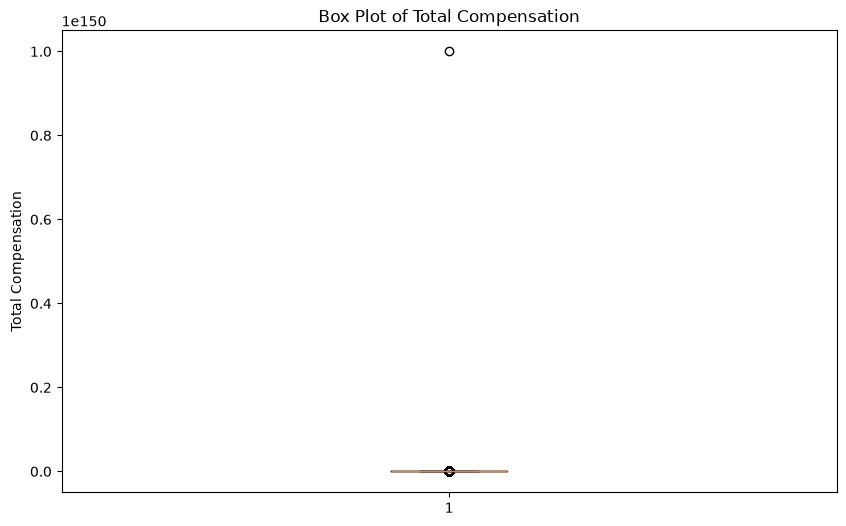

In [8]:
# your code goes here
# Get CompTotal from the database
QUERY = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""

df_comp = pd.read_sql_query(QUERY, conn)

# Convert to numeric
df_comp["CompTotal"] = pd.to_numeric(
    df_comp["CompTotal"],
    errors="coerce"
)

df_comp = df_comp.dropna()

# Create box plot
plt.figure(figsize=(10, 6))
plt.boxplot(df_comp["CompTotal"])

plt.title("Box Plot of Total Compensation")
plt.ylabel("Total Compensation")
plt.show()


**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


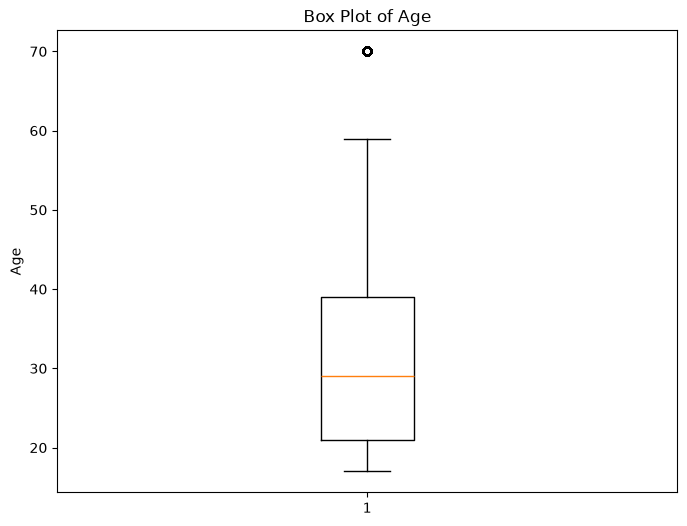

In [9]:
# your code goes here
# Get Age from database
QUERY = """
SELECT Age
FROM main
WHERE Age IS NOT NULL
"""

df_age = pd.read_sql_query(QUERY, conn)

# Convert age groups to numeric values
age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

df_age["Age_numeric"] = df_age["Age"].map(age_mapping)

# Create box plot
plt.figure(figsize=(8, 6))
plt.boxplot(df_age["Age_numeric"].dropna())

plt.title("Box Plot of Age")
plt.ylabel("Age")
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


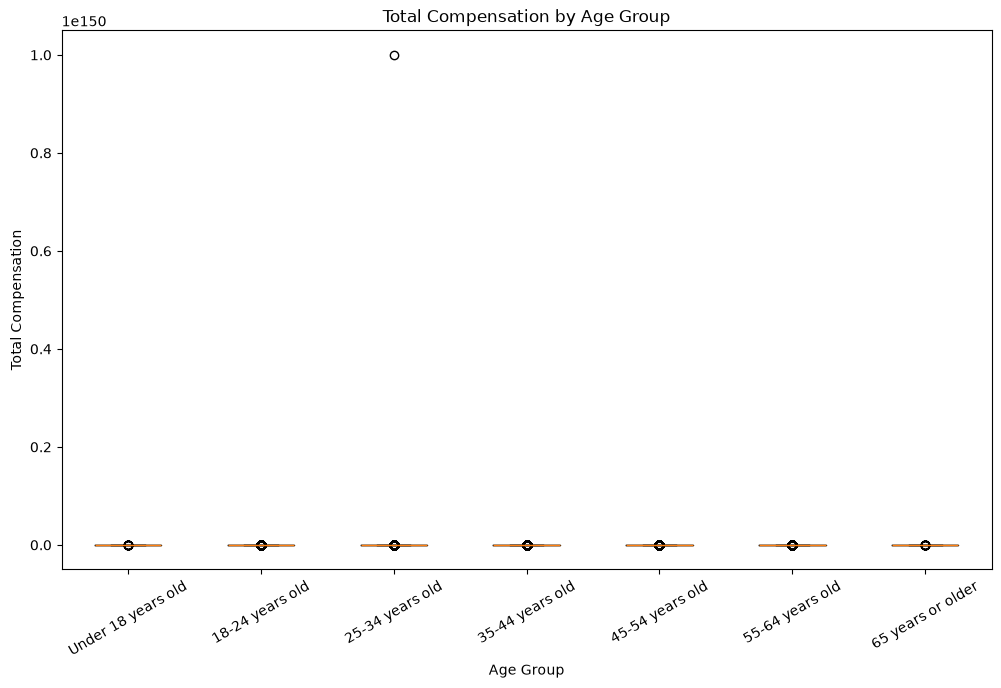

In [11]:
# Get Age and CompTotal
QUERY = """
SELECT Age, CompTotal
FROM main
WHERE Age IS NOT NULL
AND CompTotal IS NOT NULL
"""

df_age_comp = pd.read_sql_query(
    QUERY,
    conn
)

# Convert CompTotal to numeric
df_age_comp["CompTotal"] = pd.to_numeric(
    df_age_comp["CompTotal"],
    errors="coerce"
)

df_age_comp = df_age_comp.dropna(
    subset=["CompTotal"]
)

# Define age group order
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

# Prepare data
box_data = []
labels = []

for age_group in age_order:
    data = df_age_comp[
        df_age_comp["Age"] == age_group
    ]["CompTotal"].dropna()

    if len(data) > 0:
        box_data.append(data)
        labels.append(age_group)

# Create box plot
plt.figure(figsize=(12, 7))

plt.boxplot(
    box_data,
    tick_labels=labels
)

plt.title("Total Compensation by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Compensation")

plt.xticks(rotation=30)

plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


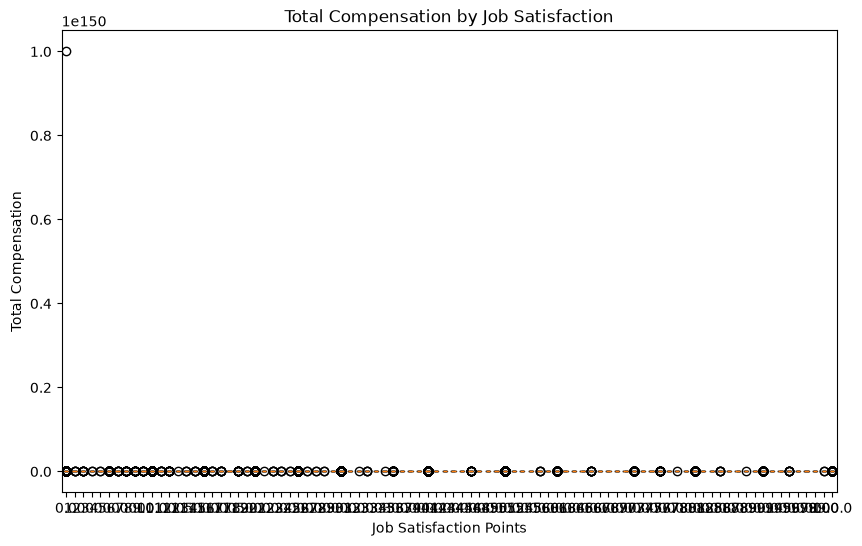

In [12]:
# your code goes here
# Get CompTotal and JobSatPoints_6
QUERY = """
SELECT CompTotal, JobSatPoints_6
FROM main
WHERE CompTotal IS NOT NULL
AND JobSatPoints_6 IS NOT NULL
"""

df_jobsat = pd.read_sql_query(
    QUERY,
    conn
)

# Convert columns to numeric
df_jobsat["CompTotal"] = pd.to_numeric(
    df_jobsat["CompTotal"],
    errors="coerce"
)

df_jobsat["JobSatPoints_6"] = pd.to_numeric(
    df_jobsat["JobSatPoints_6"],
    errors="coerce"
)

df_jobsat = df_jobsat.dropna()

# Get satisfaction levels
satisfaction_levels = sorted(
    df_jobsat["JobSatPoints_6"].unique()
)

# Prepare box plot data
box_data = []

for level in satisfaction_levels:
    data = df_jobsat[
        df_jobsat["JobSatPoints_6"] == level
    ]["CompTotal"]

    box_data.append(data)

# Create box plot
plt.figure(figsize=(10, 6))

plt.boxplot(
    box_data,
    tick_labels=satisfaction_levels
)

plt.title("Total Compensation by Job Satisfaction")
plt.xlabel("Job Satisfaction Points")
plt.ylabel("Total Compensation")

plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


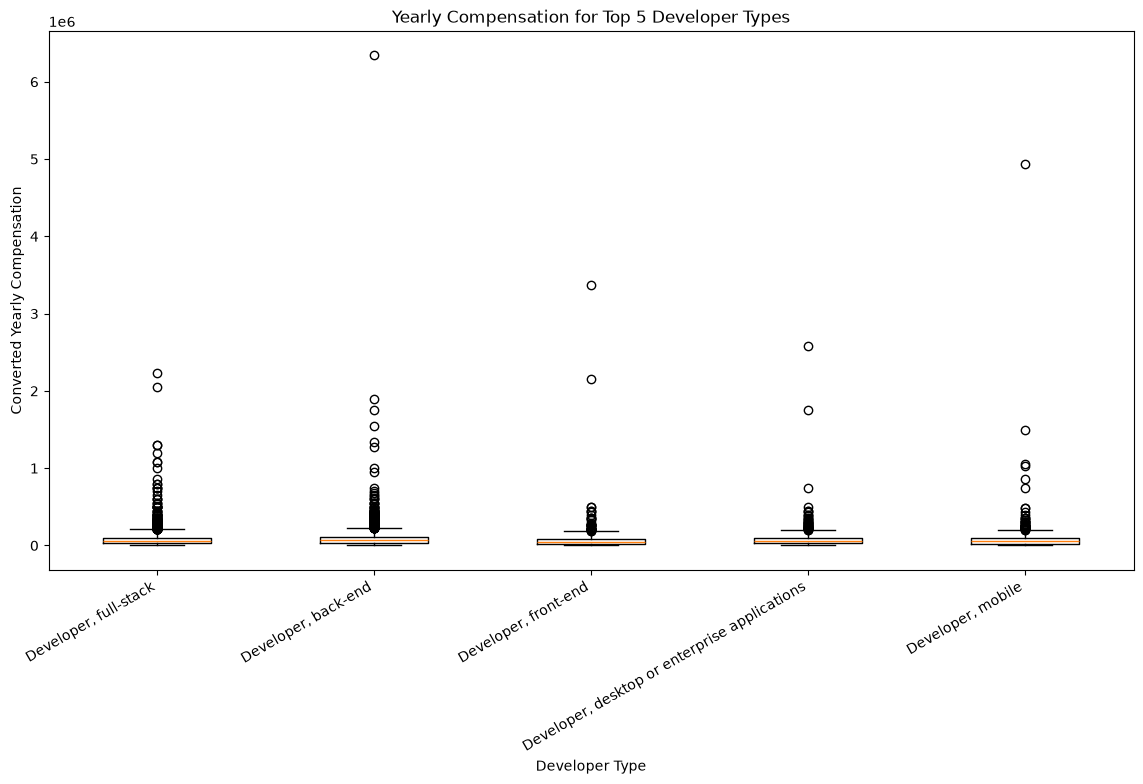

In [13]:
# your code goes here
# Get DevType and ConvertedCompYearly
QUERY = """
SELECT DevType, ConvertedCompYearly
FROM main
WHERE DevType IS NOT NULL
AND ConvertedCompYearly IS NOT NULL
"""

df_dev = pd.read_sql_query(
    QUERY,
    conn
)

# Convert compensation to numeric
df_dev["ConvertedCompYearly"] = pd.to_numeric(
    df_dev["ConvertedCompYearly"],
    errors="coerce"
)

df_dev = df_dev.dropna(
    subset=["ConvertedCompYearly"]
)

# Split multiple developer types
dev_types = (
    df_dev["DevType"]
    .str.split(";")
    .explode()
    .str.strip()
)

# Find top 5 developer types
top_5_dev_types = (
    dev_types
    .value_counts()
    .head(5)
    .index
)

# Split and explode again for plotting
df_dev_top5 = df_dev.copy()

df_dev_top5["DevType"] = (
    df_dev_top5["DevType"]
    .str.split(";")
)

df_dev_top5 = df_dev_top5.explode(
    "DevType"
)

df_dev_top5["DevType"] = (
    df_dev_top5["DevType"]
    .str.strip()
)

# Keep only top 5
df_dev_top5 = df_dev_top5[
    df_dev_top5["DevType"].isin(
        top_5_dev_types
    )
]

# Prepare box plot data
box_data = []
labels = []

for dev_type in top_5_dev_types:
    data = df_dev_top5[
        df_dev_top5["DevType"] == dev_type
    ]["ConvertedCompYearly"].dropna()

    if len(data) > 0:
        box_data.append(data)
        labels.append(dev_type)

# Create box plot
plt.figure(figsize=(14, 7))

plt.boxplot(
    box_data,
    tick_labels=labels
)

plt.title(
    "Yearly Compensation for Top 5 Developer Types"
)

plt.xlabel("Developer Type")
plt.ylabel("Converted Yearly Compensation")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


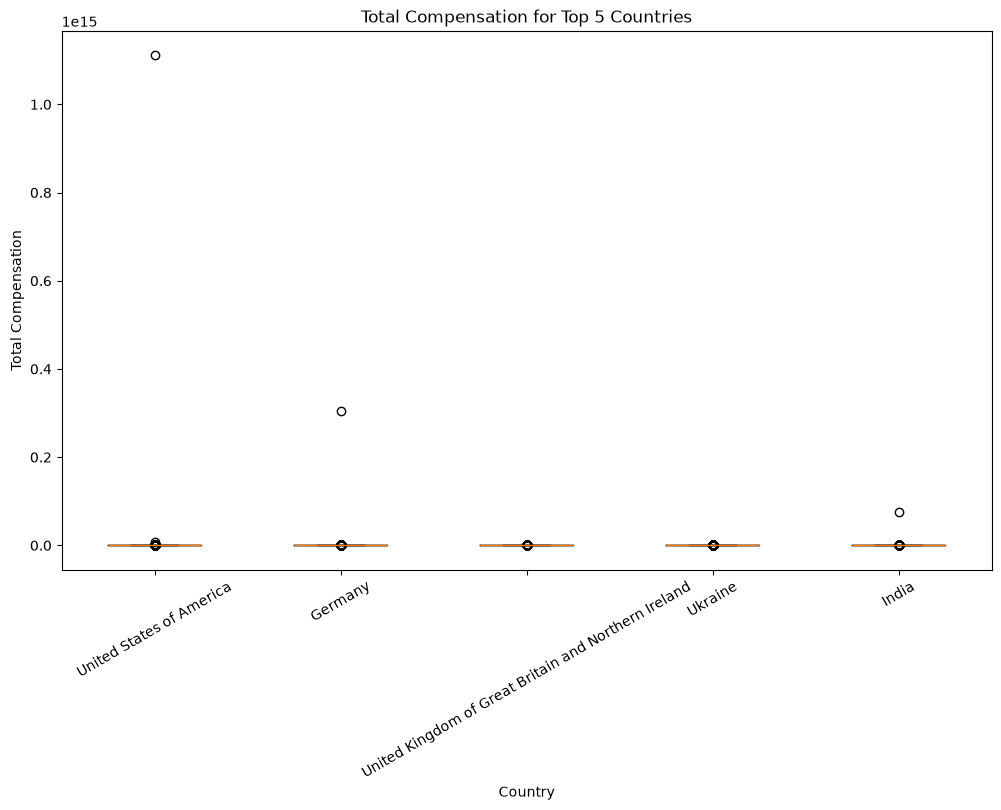

In [14]:
# your code goes here
# Get Country and CompTotal
QUERY = """
SELECT Country, CompTotal
FROM main
WHERE Country IS NOT NULL
AND CompTotal IS NOT NULL
"""

df_country = pd.read_sql_query(
    QUERY,
    conn
)

# Convert compensation to numeric
df_country["CompTotal"] = pd.to_numeric(
    df_country["CompTotal"],
    errors="coerce"
)

df_country = df_country.dropna(
    subset=["CompTotal"]
)

# Find top 5 countries
top_5_countries = (
    df_country["Country"]
    .value_counts()
    .head(5)
    .index
)

# Prepare box plot data
box_data = []
labels = []

for country in top_5_countries:
    data = df_country[
        df_country["Country"] == country
    ]["CompTotal"].dropna()

    if len(data) > 0:
        box_data.append(data)
        labels.append(country)

# Create box plot
plt.figure(figsize=(12, 7))

plt.boxplot(
    box_data,
    tick_labels=labels
)

plt.title(
    "Total Compensation for Top 5 Countries"
)

plt.xlabel("Country")
plt.ylabel("Total Compensation")

plt.xticks(rotation=30)

plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


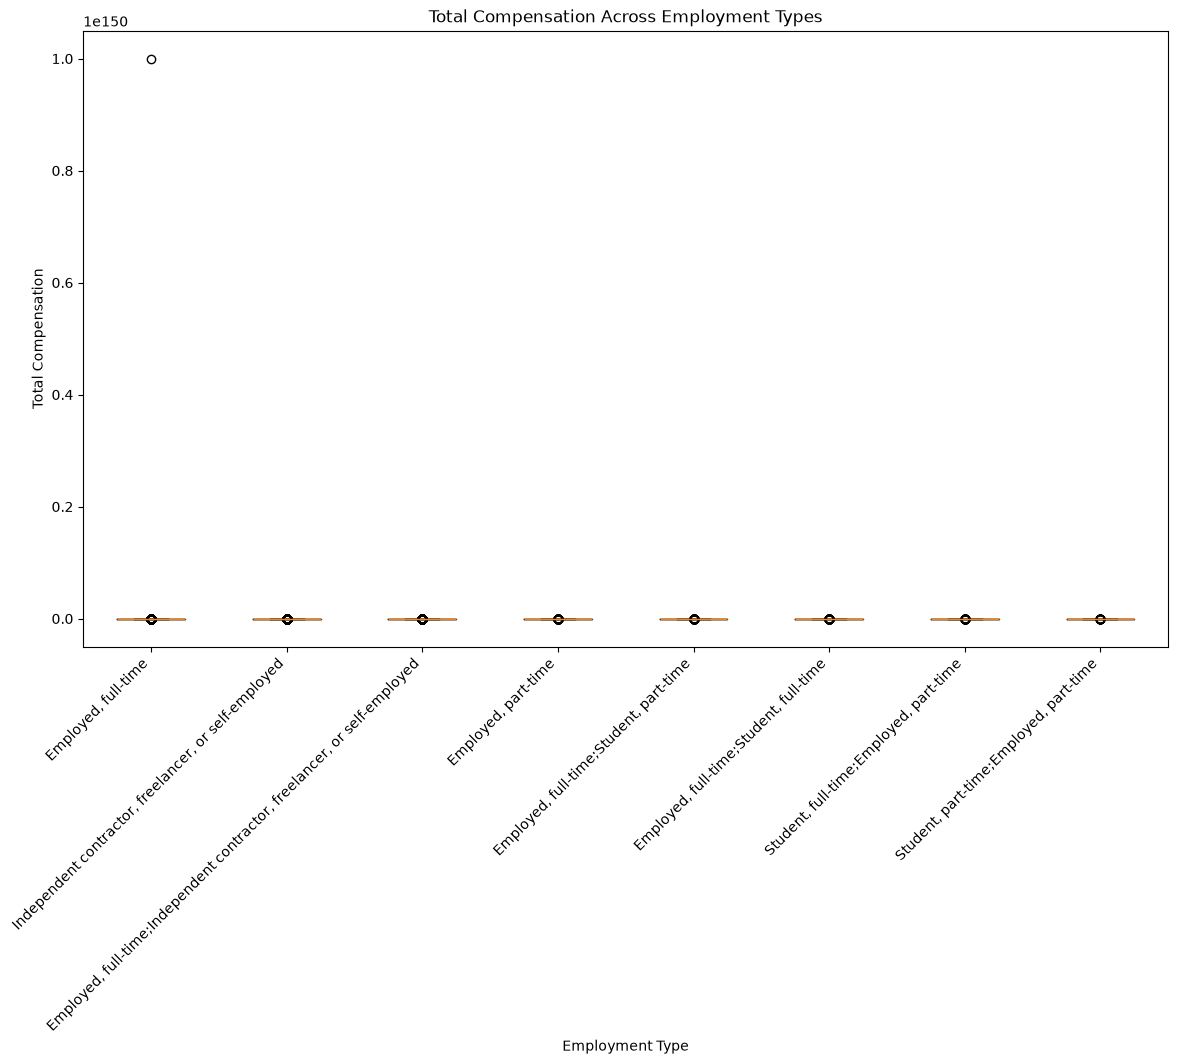

In [15]:
# your code goes here
# Get Employment and CompTotal
QUERY = """
SELECT Employment, CompTotal
FROM main
WHERE Employment IS NOT NULL
AND CompTotal IS NOT NULL
"""

df_employment = pd.read_sql_query(
    QUERY,
    conn
)

# Convert compensation to numeric
df_employment["CompTotal"] = pd.to_numeric(
    df_employment["CompTotal"],
    errors="coerce"
)

df_employment = df_employment.dropna(
    subset=["CompTotal"]
)

# Get the most common employment types
top_employment = (
    df_employment["Employment"]
    .value_counts()
    .head(8)
    .index
)

# Prepare box plot data
box_data = []
labels = []

for employment in top_employment:
    data = df_employment[
        df_employment["Employment"] == employment
    ]["CompTotal"].dropna()

    if len(data) > 0:
        box_data.append(data)
        labels.append(employment)

# Create box plot
plt.figure(figsize=(14, 8))

plt.boxplot(
    box_data,
    tick_labels=labels
)

plt.title(
    "Total Compensation Across Employment Types"
)

plt.xlabel("Employment Type")
plt.ylabel("Total Compensation")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


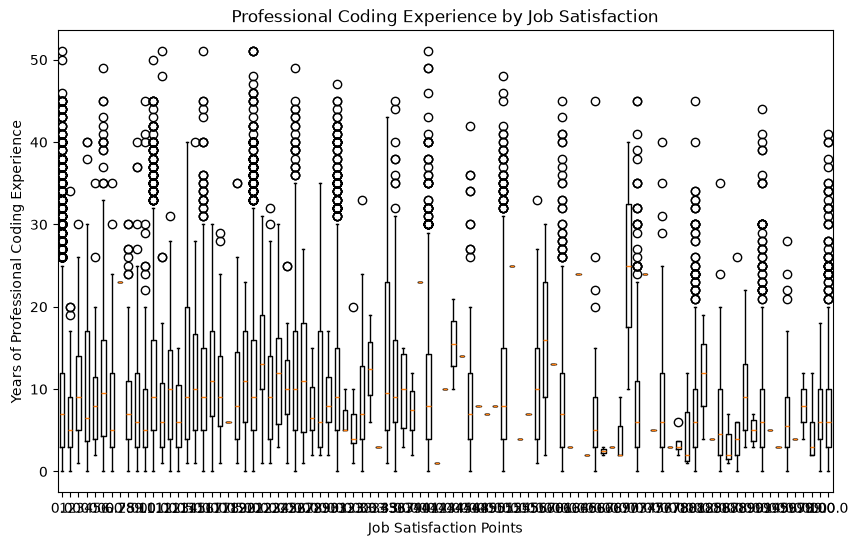

In [16]:
# your code goes here
# Get YearsCodePro and JobSatPoints_6
QUERY = """
SELECT YearsCodePro, JobSatPoints_6
FROM main
WHERE YearsCodePro IS NOT NULL
AND JobSatPoints_6 IS NOT NULL
"""

df_exp_jobsat = pd.read_sql_query(
    QUERY,
    conn
)

# Convert special YearsCodePro values
df_exp_jobsat["YearsCodePro"] = (
    df_exp_jobsat["YearsCodePro"]
    .replace({
        "Less than 1 year": "0",
        "More than 50 years": "51"
    })
)

# Convert to numeric
df_exp_jobsat["YearsCodePro"] = pd.to_numeric(
    df_exp_jobsat["YearsCodePro"],
    errors="coerce"
)

df_exp_jobsat["JobSatPoints_6"] = pd.to_numeric(
    df_exp_jobsat["JobSatPoints_6"],
    errors="coerce"
)

df_exp_jobsat = df_exp_jobsat.dropna()

# Get satisfaction levels
satisfaction_levels = sorted(
    df_exp_jobsat["JobSatPoints_6"].unique()
)

# Prepare box plot data
box_data = []
labels = []

for level in satisfaction_levels:
    data = df_exp_jobsat[
        df_exp_jobsat["JobSatPoints_6"] == level
    ]["YearsCodePro"].dropna()

    if len(data) > 0:
        box_data.append(data)
        labels.append(level)

# Create box plot
plt.figure(figsize=(10, 6))

plt.boxplot(
    box_data,
    tick_labels=labels
)

plt.title(
    "Professional Coding Experience by Job Satisfaction"
)

plt.xlabel("Job Satisfaction Points")
plt.ylabel(
    "Years of Professional Coding Experience"
)

plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [17]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
